In [6]:
# Imports and Setup
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix,
    balanced_accuracy_score, average_precision_score, auc as sk_auc
    )

# Available data paths
available_paths = [ '/space/gzanardini/tuh/tuh_singleset_final/',
                   '/space/gzanardini/tuh/tuh_singleset_noied_final/',
                   '/space/gzanardini/tuh/tuh_ss_bg',
                    '/space/gzanardini/tuh/tuh_ss_bg_noieds',
                    '/space/gzanardini/emc/emc_singleset_final/',
                    '/space/gzanardini/emc/emc_background', 
                    '/space/gzanardini/emc/emc_hypervent/']

                 
feature_types = ['spectral','cwt','dwt','mst','sst','cc','plv','gcc','gplv','utm','sa','sr']
feature_names = {'spectral': 'Spectral',
                  'cc': 'CC',
                  'cw': 'CWT', 
                  'dwt': 'DWT',
                    'gcc': 'GCC',
                  'gplv': 'GPLV',
                  'utm': 'UTM',
                  'mst': 'MST',
                  'sst': 'SST',
                  'sa': 'SA',
                  'sr': 'SR',
                  'plv': 'PLV'
                 }

print("Available data paths:")
for i, path in enumerate(available_paths):
    print(f"{i+1}. {path}")

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)

Available data paths:
1. /space/gzanardini/tuh/tuh_singleset_final/
2. /space/gzanardini/tuh/tuh_singleset_noied_final/
3. /space/gzanardini/tuh/tuh_ss_bg
4. /space/gzanardini/tuh/tuh_ss_bg_noieds
5. /space/gzanardini/emc/emc_singleset_final/
6. /space/gzanardini/emc/emc_background
7. /space/gzanardini/emc/emc_hypervent/


In [7]:
# Utility Functions for ROC and Display
pd.options.display.max_columns = 999
pd.options.display.max_rows = None
np.set_printoptions(threshold=np.inf)

plt.style.use('ggplot')

def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """Linear interpolation of TPR at FPR = x between two points."""
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)

def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """Find/interpolate TPR at a specific FPR. Assumes fpr_arr is sorted ascending."""
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    if i < 0:  # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    return interpolate(fpr_arr[i], tpr_arr[i], fpr_arr[i + 1], tpr_arr[i + 1], fprsample)

def vertical_avg_roc(roc_data):
    """Average ROC curve vertically across multiple ROC curves."""
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)

    fprs = np.sort(np.unique(fprs))
    tprs = np.zeros(shape=(len(roc_data), len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx, (fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr

def calculate_bac(labels, scores, sens_thresh):
    """
    Calculate balanced accuracy with a sensitivity threshold.
    Returns: (bac, fpr, tpr, thresholds)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    threshold_sensitivity = thresholds[np.where(tpr >= sens_thresh)[0][0]]
    adjusted_predictions = (scores >= threshold_sensitivity).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, adjusted_predictions).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    bac = ((sensitivity + specificity) / 2)
    return bac, fpr, tpr, thresholds

def compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6):
    """
    Compute the slope of the ROC threshold line for a given posterior probability.

    Parameters:
    - n_epileptic: int, number of epileptic cases in dataset
    - n_healthy: int, number of healthy subjects in dataset
    - posterior_threshold: float, required posterior probability after positive test (default=0.6)

    Returns:
    - slope: float, multiplier for FPR to get required sensitivity (ROC space)
    """
    # Prior probabilities from data
    p_epileptic = n_epileptic / (n_epileptic + n_healthy)
    p_healthy = 1 - p_epileptic

    # Calculate slope in ROC space
    slope = (posterior_threshold * p_healthy) / (p_epileptic * (1 - posterior_threshold))

    return slope

In [8]:
def analyze_set_performance(datafolder, save_plots=True, plot_prefix="ensemble"):
    """
    Analyze single feature set performance from prediction files.
    
    Parameters:
    -----------
    datafolder : str
        Path to the folder containing prediction CSV files
    save_plots : bool
        Whether to save plots to files
    plot_prefix : str
        Prefix for saved plot filenames
        
    Returns:
    --------
    tuple : (df_summary, df_best, std_df)
        Summary dataframe, best combinations dataframe, and standard deviation dataframe
    """
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    print(f"Analyzing data from: {datafolder}")
    
    # List all prediction files
    files = [file for file in os.listdir(datafolder) if file.endswith('.csv')]
    print(f"Found {len(files)} prediction files.")
    
    if len(files) == 0:
        print("No prediction files found!")
        return None, None, None
    

    df_summary = pd.DataFrame(columns=[
        'feature_type', 'montage', 'length', 'combiner', 'accuracy', 'bac', 'bac80', 'f1_score',
        'precision', 'recall', 'auc', 'auprc', 'AP'
    ])

    # Analyze single feature sets
    for feature_type in feature_types:
        try:
            # Look for files matching the pattern: predictions_{montage}_{feature_type}_{length}s_{combiner}_run_{number}_seed_{seed}.csv
            feature_files = [file for file in files if f'_{feature_type}_' in file and 'predictions' in file]
            
            if not feature_files:
                print(f"No files found for feature type: {feature_type}")
                continue
                
            print(f"Processing feature type: {feature_type} with {len(feature_files)} files")
            
            for file in feature_files:
                try:
                    # Parse filename to extract parameters
                    # Format: predictions_{montage}_{feature_type}_{length}s_{combiner}_run_{number}_seed_{seed}.csv
                    parts = file.replace('predictions_', '').replace('.csv', '').split('_')
                    
                    # Find the feature_type position and extract parameters
                    feature_idx = -1
                    for i, part in enumerate(parts):
                        if part == feature_type:
                            feature_idx = i
                            break
                    
                    if feature_idx == -1:
                        print(f"Could not parse feature type from filename: {file}")
                        continue
                    
                    montage = parts[0] if feature_idx > 0 else "unknown"
                    length_part = parts[feature_idx + 1] if feature_idx + 1 < len(parts) else "unknown"
                    length = length_part.replace('s', '') if length_part.endswith('s') else length_part
                    combiner = parts[feature_idx + 2] if feature_idx + 2 < len(parts) else "unknown"
                    
                    df_file = pd.read_csv(os.path.join(datafolder, file))
                    accuracy = accuracy_score(df_file['y_tests'], df_file['y_preds'])
                    f1 = f1_score(df_file['y_tests'], df_file['y_preds'])
                    precision = precision_score(df_file['y_tests'], df_file['y_preds'])
                    recall = recall_score(df_file['y_tests'], df_file['y_preds'])
                    auc = roc_auc_score(df_file['y_tests'], df_file['y_scores'])
                    bac = balanced_accuracy_score(df_file['y_tests'], df_file['y_preds'])
                    bac80, fpr, tpr, thresholds = calculate_bac(df_file['y_tests'], df_file['y_scores'], 0.80)
                    p, r, t = precision_recall_curve(df_file['y_tests'], df_file['y_scores'])
                    auprc = sk_auc(r, p)
                    ap = average_precision_score(df_file['y_tests'], df_file['y_scores'])
                    
                    df_summary = pd.concat([df_summary, pd.DataFrame([[feature_type, montage, length, combiner, accuracy, bac, bac80, f1, precision, recall, auc, auprc, ap]],
                                                    columns=df_summary.columns)], ignore_index=True)
                except Exception as e:
                    print(f"Error processing file {file}: {e}")
                    continue
                    
        except Exception as e:
            print(f"Error processing feature type {feature_type}: {e}")
            continue
    
    # Group by feature type and parameter combination to get average performance
    param_combinations = df_summary.groupby(['feature_type', 'montage', 'length', 'combiner']).agg({
        'accuracy': 'mean',
        'bac': 'mean', 
        'bac80': 'mean',
        'f1_score': 'mean',
        'precision': 'mean',
        'recall': 'mean',
        'auc': 'mean',
        'auprc': 'mean',
        'AP': 'mean'
    }).reset_index()
    
    # Find best performing combination for each feature type based on AUC
    df_best = []
    for feature_type in df_summary['feature_type'].unique():
        feature_data = param_combinations[param_combinations['feature_type'] == feature_type].copy()
        #define a new column as auc + bac80
        feature_data['score'] = feature_data['auc'] + feature_data['bac']

        if not feature_data.empty:
            best_idx = feature_data['score'].idxmax()
            best_combo = feature_data.loc[best_idx].copy()
            df_best.append(best_combo)
    
    df_best = pd.DataFrame(df_best)
    
    # Check if we have any results
    if df_best.empty:
        print("No valid feature combinations found!")
        return None, None, None
        
    df_best = df_best.sort_values(by='auc', ascending=False).reset_index(drop=True)

    
    # Compute Standard Deviation for Best Combinations only
    std_df = []
    for _, row in df_best.iterrows():
        feature_type = row['feature_type']
        montage = row['montage']
        length = row['length']
        combiner = row['combiner']
        
        # Get all runs for this specific combination
        combo_data = df_summary[
            (df_summary['feature_type'] == feature_type) &
            (df_summary['montage'] == montage) &
            (df_summary['length'] == length) &
            (df_summary['combiner'] == combiner)
        ]
        
        if not combo_data.empty:
            std_row = combo_data.std()
            std_row['feature_type'] = feature_type
            std_row['montage'] = montage
            std_row['length'] = length
            std_row['combiner'] = combiner
            std_df.append(std_row)
    
    std_df = pd.DataFrame(std_df)
    
    # Create combined table with mean ± std format
    combined_df = df_best.copy()
    
    # Merge with std_df to get standard deviations
    merge_cols = ['feature_type', 'montage', 'length', 'combiner']
    metric_cols = ['accuracy', 'bac', 'bac80', 'f1_score', 'precision', 'recall', 'auc', 'auprc']
    
    combined_df = combined_df.merge(std_df[merge_cols + metric_cols], 
                                   on=merge_cols, suffixes=('_mean', '_std'))
    
    # Create formatted columns with mean ± std
    formatted_df = pd.DataFrame()
    formatted_df['feature_type'] = combined_df['feature_type']
    formatted_df['montage'] = combined_df['montage']
    formatted_df['length'] = combined_df['length']
    formatted_df['combiner'] = combined_df['combiner']
    
    for metric in metric_cols:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        formatted_df[metric] = combined_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    
    print("\n" + "="*120)
    print("BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)")
    print("="*120)
    print(formatted_df.to_string(index=False))
    
    # Alternative format: Interleaved table with std columns following metrics
    alt_df = pd.DataFrame()
    alt_df['feature_type'] = combined_df['feature_type']
    alt_df['montage'] = combined_df['montage']
    alt_df['length'] = combined_df['length']
    alt_df['combiner'] = combined_df['combiner']
    
    for metric in metric_cols:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        alt_df[metric] = combined_df[mean_col].round(3)
        alt_df[f'{metric}_std'] = combined_df[std_col].round(3)
    

    print("\n" + "="*180)
    print("ALTERNATIVE FORMAT: BEST COMBINATIONS WITH INTERLEAVED STANDARD DEVIATIONS")
    print("="*180)
    print(alt_df.to_string(index=False))
    
    # Plot ROC Curves for Best Features
    plt.figure(figsize=(8, 8))

    for index, row in df_best.iterrows():
        feature_type = row['feature_type']
        montage = row['montage']
        length = row['length']
        combiner = row['combiner']
        
        # Find files matching this specific combination
        pattern_files = []
        for file in files:
            if (f'_{feature_type}_' in file and 
                f'predictions_{montage}_' in file and
                f'_{length}s_' in file and
                f'_{combiner}_' in file):
                pattern_files.append(file)
        
        print(f"Processing {feature_type} ({montage}, {length}s, {combiner}) with files: {pattern_files}")
        
        roc_data = []
        for file in pattern_files:
            try:
                df_file = pd.read_csv(os.path.join(datafolder, file))
                fpr, tpr, thresholds = roc_curve(df_file['y_tests'], df_file['y_scores'])
                roc_data.append((fpr, tpr, thresholds))
            except Exception as e:
                print(f"Error processing file {file} for ROC: {e}")
                continue
        
        if roc_data:
            fpr_avg, tpr_avg = vertical_avg_roc(roc_data)
            auc_avg = sk_auc(fpr_avg, tpr_avg)
            label = f"{feature_type} ({montage}, {length}s, {combiner}) AUC={row['auc']:.2f}"
            plt.step(fpr_avg, tpr_avg, label=label, color=colors[index % len(colors)], alpha=0.7)

    # Get class distribution from last processed file
    if 'df_file' in locals():
        n_epileptic = np.sum(df_file['y_tests'])
        n_healthy = len(df_file['y_tests']) - n_epileptic

        slope=compute_threshold_slope(n_epileptic, n_healthy, 0.6)
        # plot a line with this slope, limit the y axis to [0, 1]
        plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
        #fill above the line
        plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$\geq$0.6')


    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.legend(loc='lower right', fontsize=8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves of Best Feature Types')
    plt.grid(True)
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{plot_prefix}_best_feature_roc_curves.pdf', dpi=300)
    plt.show()
    
    # Plot Boxplots for Score Distributions
    n_features = len(df_best)
    if n_features > 0:
        # Calculate grid dimensions
        n_cols = min(3, n_features)
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
        
        # Ensure axes is always a 2D array
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)

        for idx, row in df_best.iterrows():
            feature_type = row['feature_type']
            montage = row['montage']
            length = row['length']
            combiner = row['combiner']
            
            # Find files matching this specific combination
            pattern_files = []
            for file in files:
                if (f'_{feature_type}_' in file and 
                    f'predictions_{montage}_' in file and
                    f'_{length}s_' in file and
                    f'_{combiner}_' in file):
                    pattern_files.append(file)

            # Collect all scores for each class
            scores_class_0 = []
            scores_class_1 = []

            for file in pattern_files:
                try:
                    df_file = pd.read_csv(os.path.join(datafolder, file))
                    scores_class_0.extend(df_file.loc[df_file['y_tests'] == 0, 'y_scores'].values)
                    scores_class_1.extend(df_file.loc[df_file['y_tests'] == 1, 'y_scores'].values)
                except Exception as e:
                    print(f"Error processing file {file} for boxplot: {e}")
                    continue

            if scores_class_0 and scores_class_1:
                data = [scores_class_0, scores_class_1]

                # Calculate subplot position
                row_idx = idx // n_cols
                col_idx = idx % n_cols
                ax = axes[row_idx, col_idx]

                # plot a boxplot with empty boxes (no fill)
                ax.boxplot(
                    data, positions=[0, 1], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='none', edgecolor='black'),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    showfliers=False
                )

                # plot the scatter plot behind the boxplot
                jitter = 0.1
                x0 = np.random.normal(0, jitter, size=len(scores_class_0))
                x1 = np.random.normal(1, jitter, size=len(scores_class_1))
                ax.scatter(x0, scores_class_0, alpha=0.3, color='tab:blue', s=10, label='Healthy' if idx == 0 else "")
                ax.scatter(x1, scores_class_1, alpha=0.3, color='tab:orange', s=10, label='Epileptic' if idx == 0 else "")
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['Healthy', 'Epileptic'])
                ax.set_title(f'{feature_type}\n({montage}, {length}s, {combiner})\nAUC: {row["auc"]:.2f}', fontsize=9)
                ax.set_ylim(0, 1)
                
                if idx == 0:  # Add legend to the first subplot only
                    ax.legend(['Healthy', 'Epileptic'], loc='upper right', fontsize=8)

        # Hide unused subplots
        for idx in range(n_features, n_rows * n_cols):
            row_idx = idx // n_cols
            col_idx = idx % n_cols
            axes[row_idx, col_idx].set_visible(False)

        plt.suptitle('Score Distributions for Best Feature Types')
        plt.tight_layout()
        if save_plots:
            plt.savefig(f'{plot_prefix}_best_feature_boxplots.pdf', dpi=300)
        plt.show()

    return df_summary, df_best, std_df

<>:248: SyntaxWarning: invalid escape sequence '\g'
<>:248: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_238958/748418659.py:248: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='P(Epilepsy|y=1)$\geq$0.6')


Analyzing data from: /space/gzanardini/tuh/tuh_singleset_final/
Found 13260 prediction files.
Processing feature type: spectral with 360 files
Processing feature type: cwt with 360 files
Processing feature type: dwt with 360 files
Processing feature type: mst with 360 files
Processing feature type: sst with 360 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Processing feature type: cc with 417 files
Processing feature type: plv with 360 files
Processing feature type: gcc with 360 files
Processing feature type: gplv with 360 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Processing feature type: utm with 360 files
No files found for feature type: sa
No files found for feature type: sr

BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)
feature_type   montage length combiner      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
         utm Laplacian     60     mean 0.817 ± 0.014 0.758 ± 0.022 0.819 ± 0.022 0.676 ± 0.034 0.793 ± 0.013 0.590 ± 0.044 0.875 ± 0.008 0.769 ± 0.002
         plv       CAR      1   median 0.775 ± 0.025 0.760 ± 0.029 0.756 ± 0.019 0.675 ± 0.036 0.637 ± 0.034 0.718 ± 0.044 0.821 ± 0.010 0.601 ± 0.021
         cwt BipolarDB     60      std 0.767 ± 0.014 0.708 ± 0.011 0.819 ± 0.022 0.600 ± 0.015 0.679 ± 0.037 0.538 ± 0.000 0.818 ± 0.005 0.682 ± 0.023
    spectral       CAR      1     skew 0.775 ± 0.025 0.727 ± 0.010 0.739 ± 0.033 0.631 ± 0.013 0.687 ± 0.083 0.590 ± 0.044 0.811 ± 0.009 0.687 ± 0.019
         sst       CAR      2     kurt 0.767 ± 0.014 0.721 ± 0.02

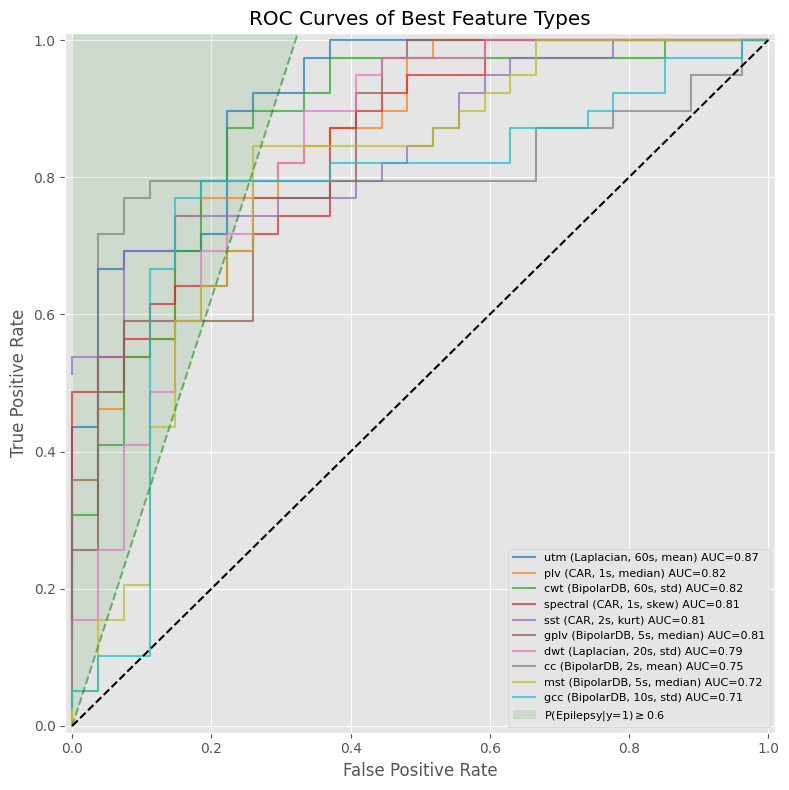

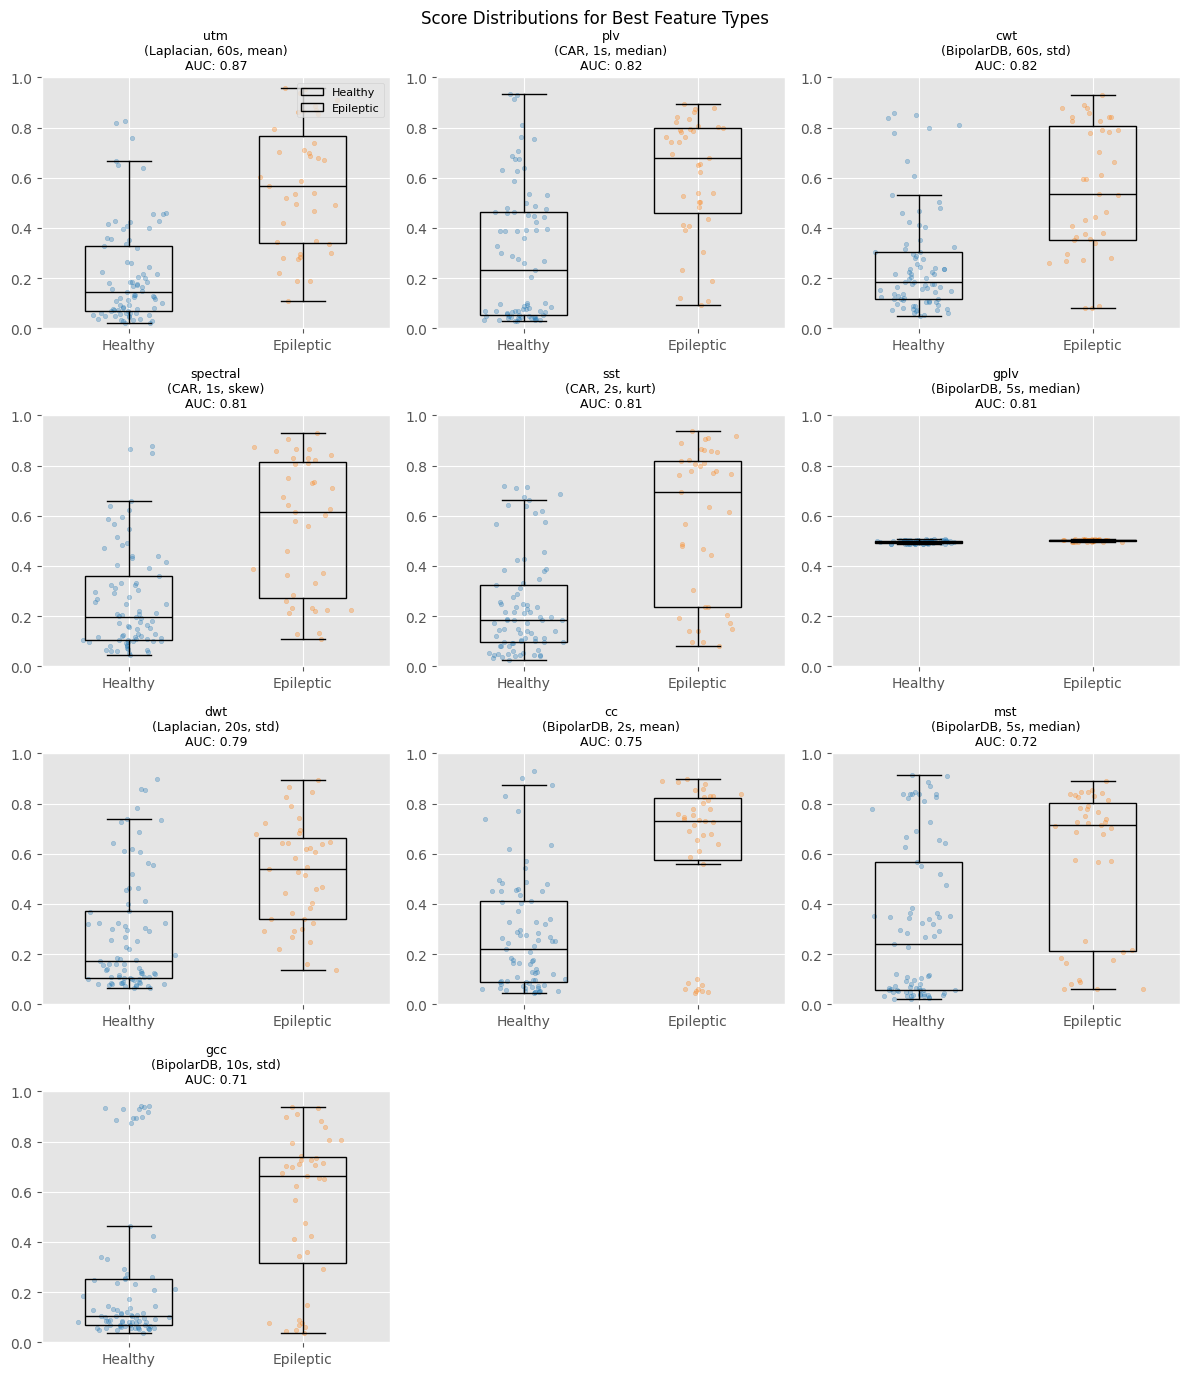

Analyzing data from: /space/gzanardini/tuh/tuh_singleset_noied_final/
Found 8400 prediction files.
Processing feature type: spectral with 360 files
Processing feature type: cwt with 360 files
Processing feature type: dwt with 360 files
Processing feature type: mst with 360 files
Processing feature type: sst with 360 files
Processing feature type: cc with 360 files
Processing feature type: plv with 360 files
Processing feature type: gcc with 360 files
Processing feature type: gplv with 360 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Processing feature type: utm with 360 files
No files found for feature type: sa
No files found for feature type: sr

BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)
feature_type   montage length combiner      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
         sst Laplacian     20     skew 0.825 ± 0.015 0.769 ± 0.011 0.854 ± 0.000 0.678 ± 0.019 0.726 ± 0.045 0.636 ± 0.000 0.845 ± 0.012 0.635 ± 0.051
    spectral       CAR     20      std 0.807 ± 0.015 0.756 ± 0.011 0.847 ± 0.014 0.657 ± 0.017 0.679 ± 0.037 0.636 ± 0.000 0.842 ± 0.003 0.630 ± 0.005
         plv BipolarDB      5   median 0.825 ± 0.015 0.787 ± 0.023 0.779 ± 0.049 0.697 ± 0.030 0.698 ± 0.030 0.697 ± 0.052 0.834 ± 0.022 0.686 ± 0.044
         cwt BipolarDB     20      std 0.781 ± 0.015 0.747 ± 0.023 0.801 ± 0.023 0.637 ± 0.029 0.612 ± 0.027 0.667 ± 0.052 0.832 ± 0.025 0.569 ± 0.043
          cc        Cz     60   median 0.807 ± 0.040 0.774 ± 0.03

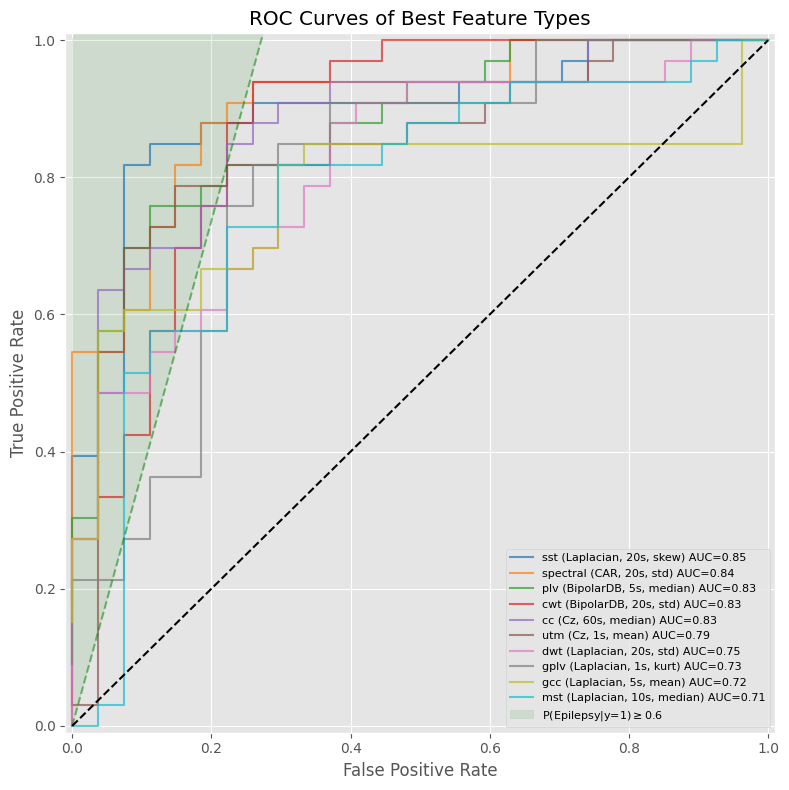

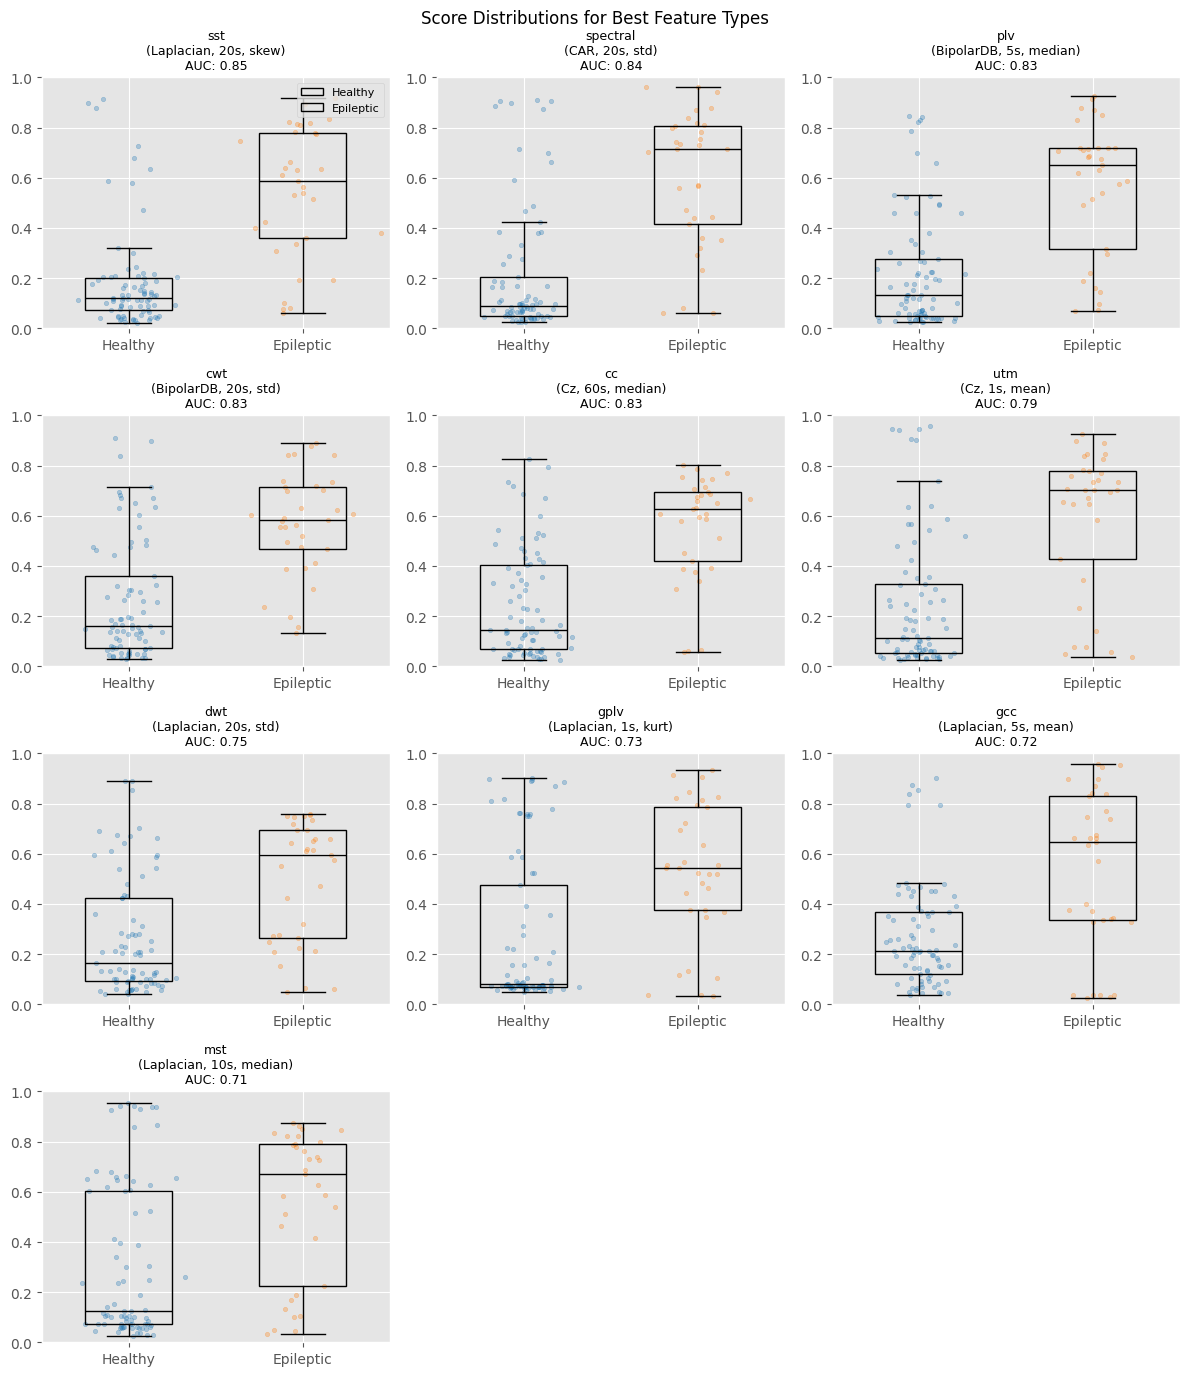

Analyzing data from: /space/gzanardini/tuh/tuh_ss_bg
Found 4170 prediction files.
Processing feature type: spectral with 420 files
Processing feature type: cwt with 420 files
Processing feature type: dwt with 420 files
Processing feature type: mst with 420 files
Processing feature type: sst with 420 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Processing feature type: cc with 420 files
Processing feature type: plv with 420 files
Processing feature type: gcc with 390 files
Processing feature type: gplv with 420 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Processing feature type: utm with 420 files
No files found for feature type: sa
No files found for feature type: sr

BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)
feature_type   montage length combiner      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
         utm Laplacian     60   median 0.825 ± 0.000 0.830 ± 0.000 0.855 ± 0.021 0.759 ± 0.000 0.688 ± 0.000 0.846 ± 0.000 0.929 ± 0.012 0.883 ± 0.014
    spectral BipolarDB      2     kurt 0.825 ± 0.025 0.791 ± 0.038 0.830 ± 0.019 0.719 ± 0.051 0.749 ± 0.021 0.692 ± 0.077 0.858 ± 0.013 0.807 ± 0.018
         plv        Cz     60      std 0.767 ± 0.014 0.708 ± 0.011 0.807 ± 0.092 0.600 ± 0.015 0.679 ± 0.037 0.538 ± 0.000 0.847 ± 0.034 0.713 ± 0.044
         cwt        Cz     10     kurt 0.808 ± 0.038 0.752 ± 0.051 0.695 ± 0.028 0.665 ± 0.075 0.765 ± 0.060 0.590 ± 0.089 0.819 ± 0.010 0.768 ± 0.010
          cc       CAR    120     mean 0.758 ± 0.014 0.715 ± 0.01

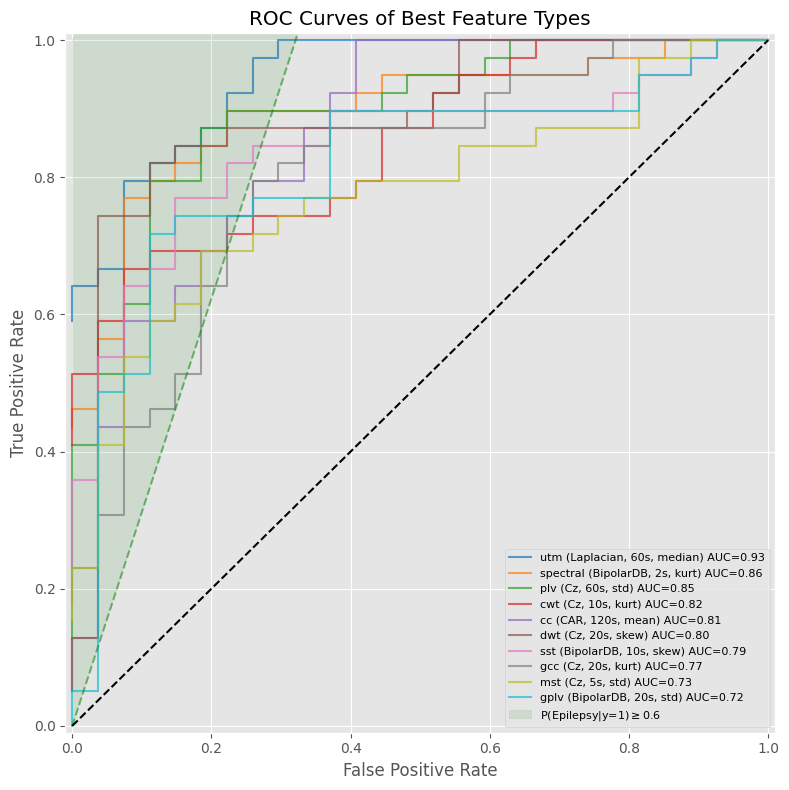

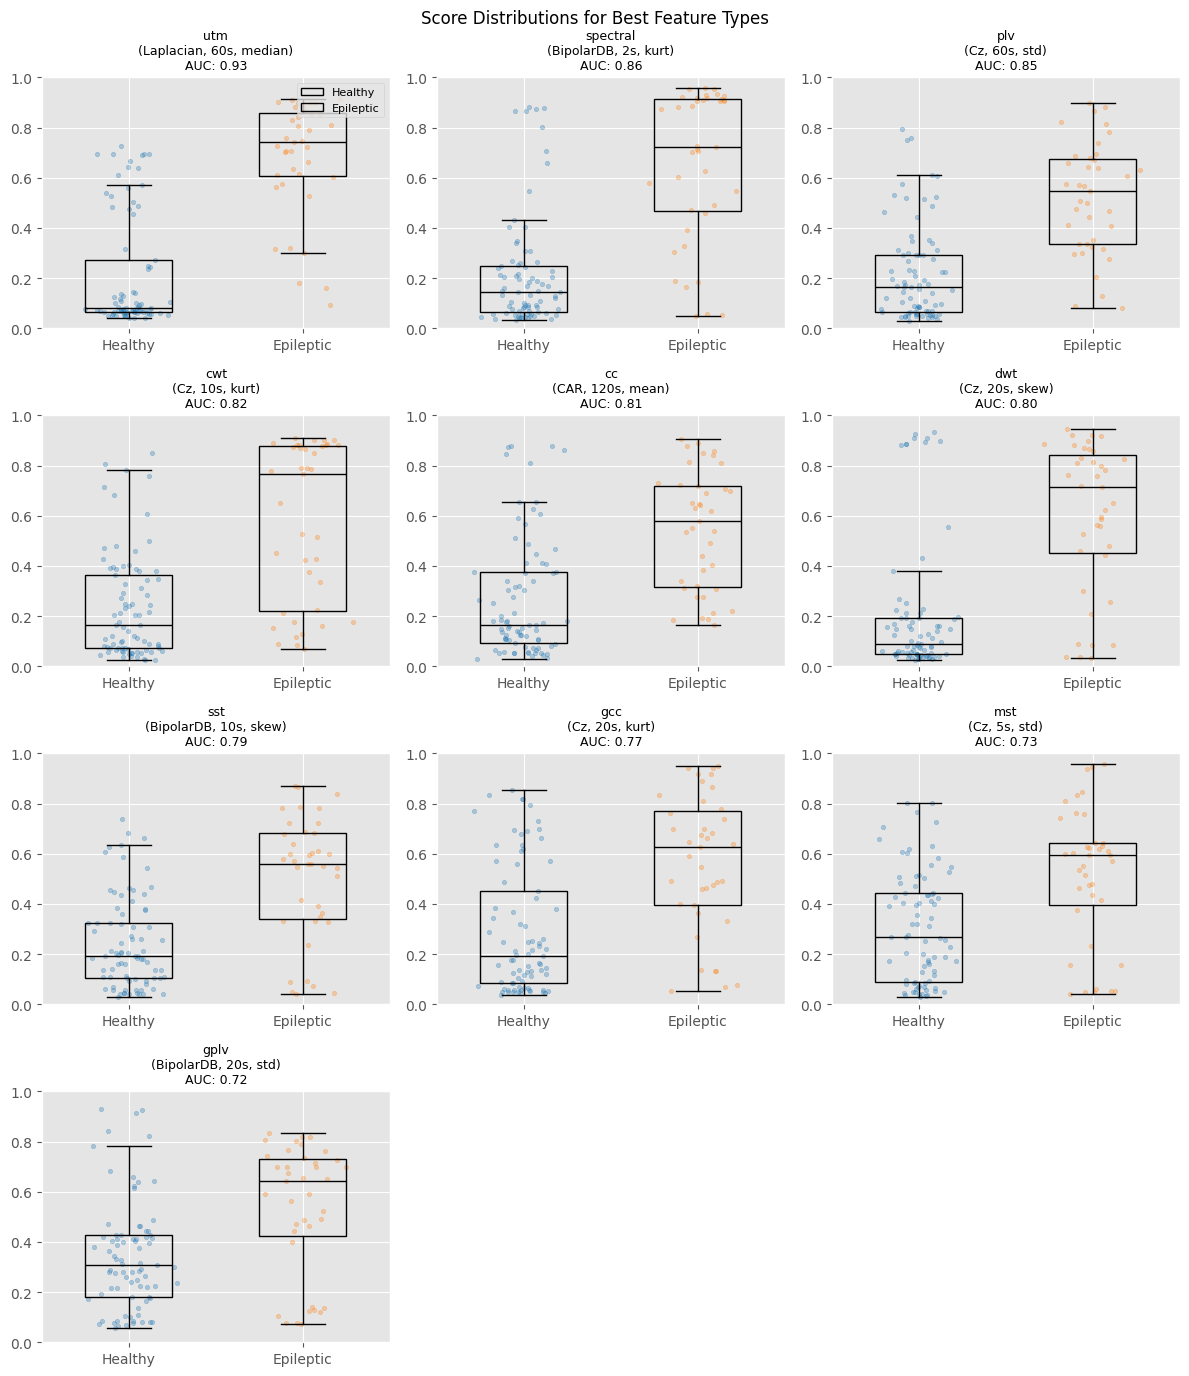

Analyzing data from: /space/gzanardini/tuh/tuh_ss_bg_noieds
Found 4170 prediction files.
Processing feature type: spectral with 420 files
Processing feature type: cwt with 420 files
Processing feature type: dwt with 420 files
Processing feature type: mst with 420 files
Processing feature type: sst with 420 files
Processing feature type: cc with 420 files
Processing feature type: plv with 420 files
Processing feature type: gcc with 390 files
Processing feature type: gplv with 420 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

Processing feature type: utm with 420 files
No files found for feature type: sa
No files found for feature type: sr

BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)
feature_type   montage length combiner      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
         sst BipolarDB     10     skew 0.807 ± 0.040 0.730 ± 0.055 0.869 ± 0.026 0.619 ± 0.087 0.718 ± 0.081 0.545 ± 0.091 0.868 ± 0.007 0.798 ± 0.010
         plv BipolarDB      5     kurt 0.772 ± 0.030 0.669 ± 0.037 0.798 ± 0.067 0.519 ± 0.064 0.667 ± 0.082 0.424 ± 0.052 0.865 ± 0.038 0.706 ± 0.039
         utm       CAR      2     skew 0.842 ± 0.000 0.808 ± 0.000 0.810 ± 0.011 0.727 ± 0.000 0.727 ± 0.000 0.727 ± 0.000 0.862 ± 0.012 0.769 ± 0.026
    spectral BipolarDB      2     kurt 0.816 ± 0.026 0.763 ± 0.045 0.816 ± 0.000 0.665 ± 0.064 0.698 ± 0.030 0.636 ± 0.091 0.852 ± 0.015 0.757 ± 0.006
         dwt        Cz     60     skew 0.781 ± 0.015 0.711 ± 0.01

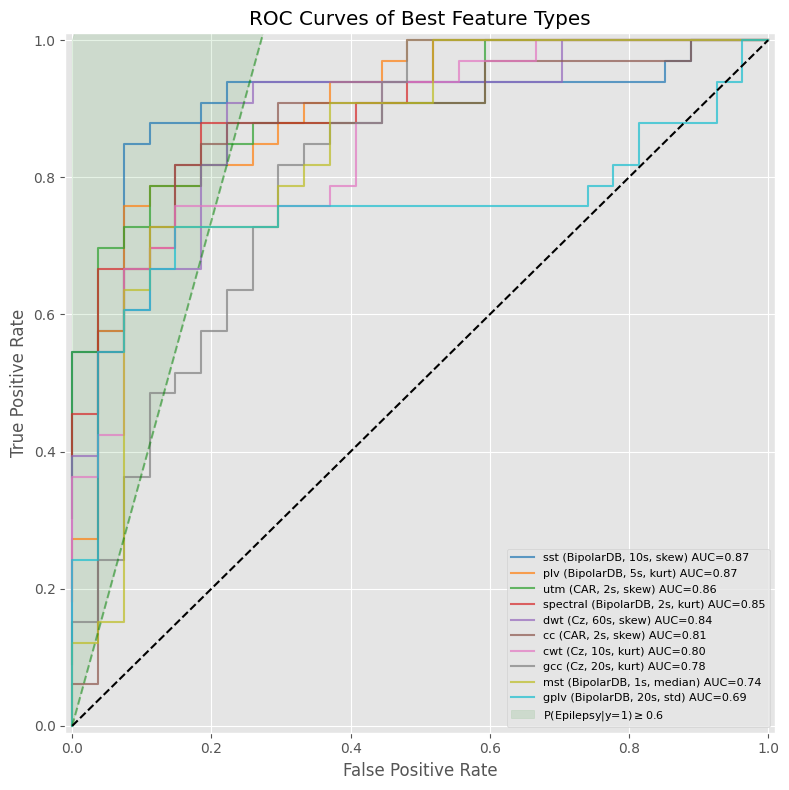

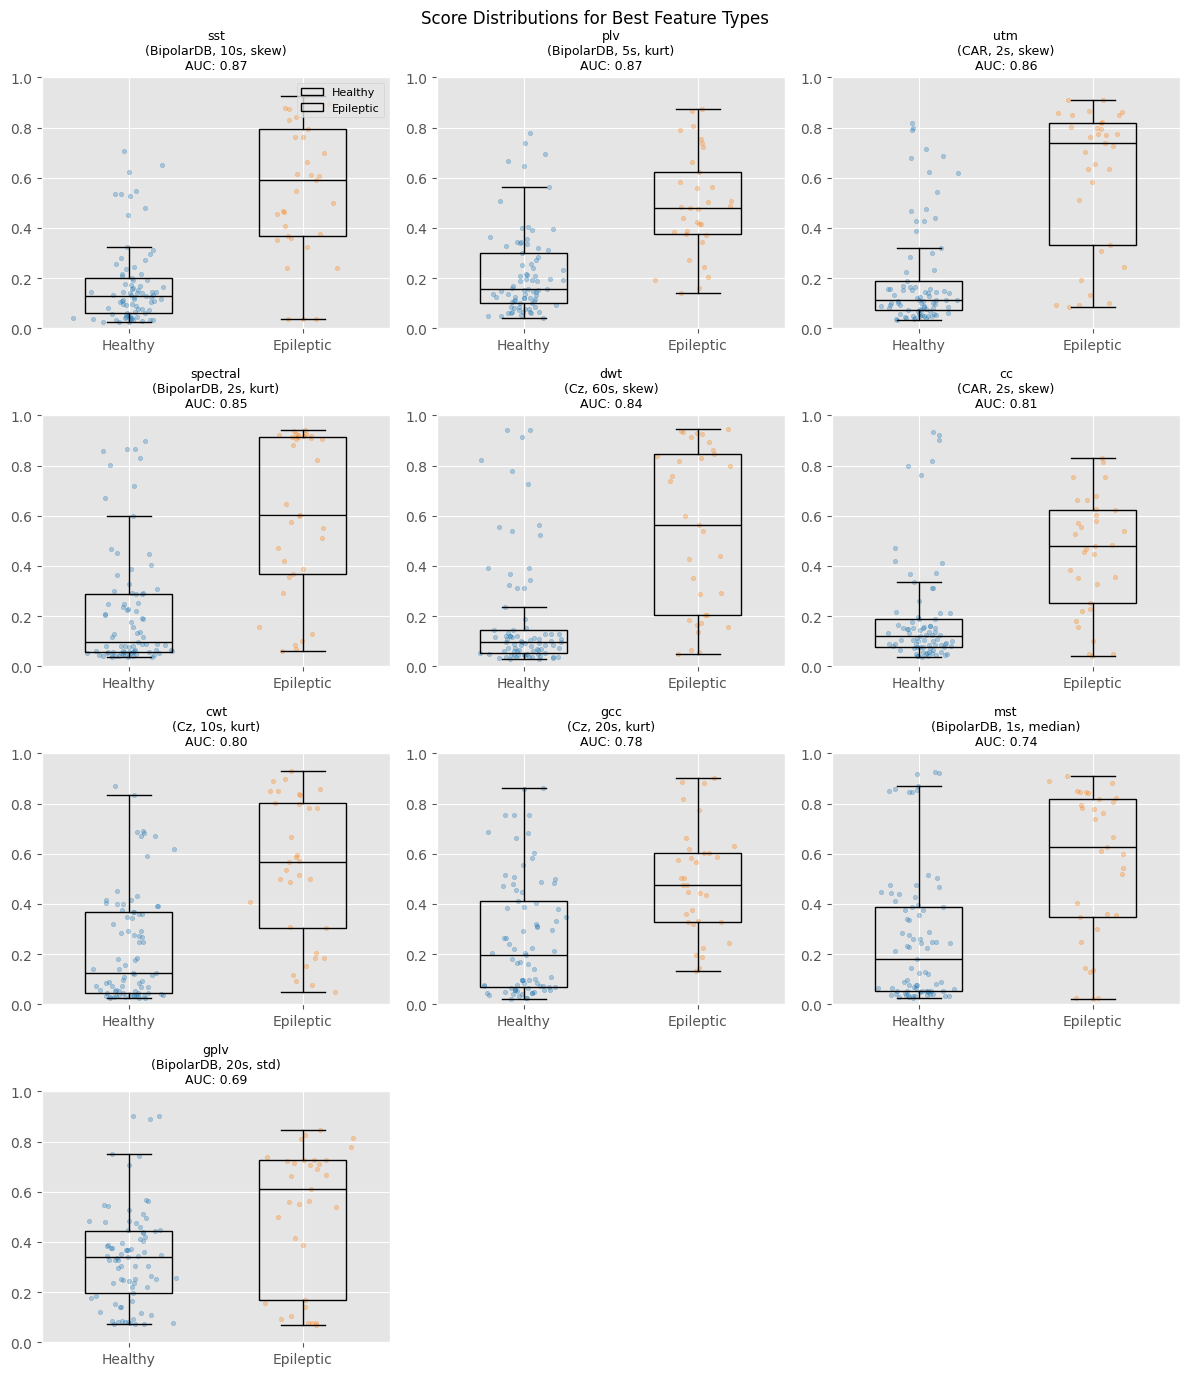

Analyzing data from: /space/gzanardini/emc/emc_singleset_final/
Found 11321 prediction files.
Processing feature type: spectral with 600 files
Processing feature type: cwt with 600 files
Processing feature type: dwt with 600 files
Processing feature type: mst with 600 files
Processing feature type: sst with 600 files


/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Processing feature type: cc with 600 files
Processing feature type: plv with 600 files
Processing feature type: gcc with 600 files
Processing feature type: gplv with 600 files
Processing feature type: utm with 600 files
No files found for feature type: sa
No files found for feature type: sr

BEST PARAMETER COMBINATIONS FOR EACH FEATURE TYPE (Mean ± Std)
feature_type   montage length combiner      accuracy           bac         bac80      f1_score     precision        recall           auc         auprc
         plv       CAR     20     mean 0.738 ± 0.014 0.598 ± 0.013 0.681 ± 0.025 0.373 ± 0.023 0.583 ± 0.060 0.275 ± 0.018 0.733 ± 0.023 0.500 ± 0.040
          cc       CAR      1      std 0.760 ± 0.006 0.656 ± 0.008 0.633 ± 0.014 0.495 ± 0.015 0.616 ± 0.020 0.415 ± 0.022 0.721 ± 0.015 0.537 ± 0.035
         cwt BipolarDB      5   median 0.726 ± 0.013 0.620 ± 0.018 0.640 ± 0.024 0.437 ± 0.033 0.525 ± 0.031 0.375 ± 0.040 0.705 ± 0.019 0.481 ± 0.021
         sst       CAR     10   median 0

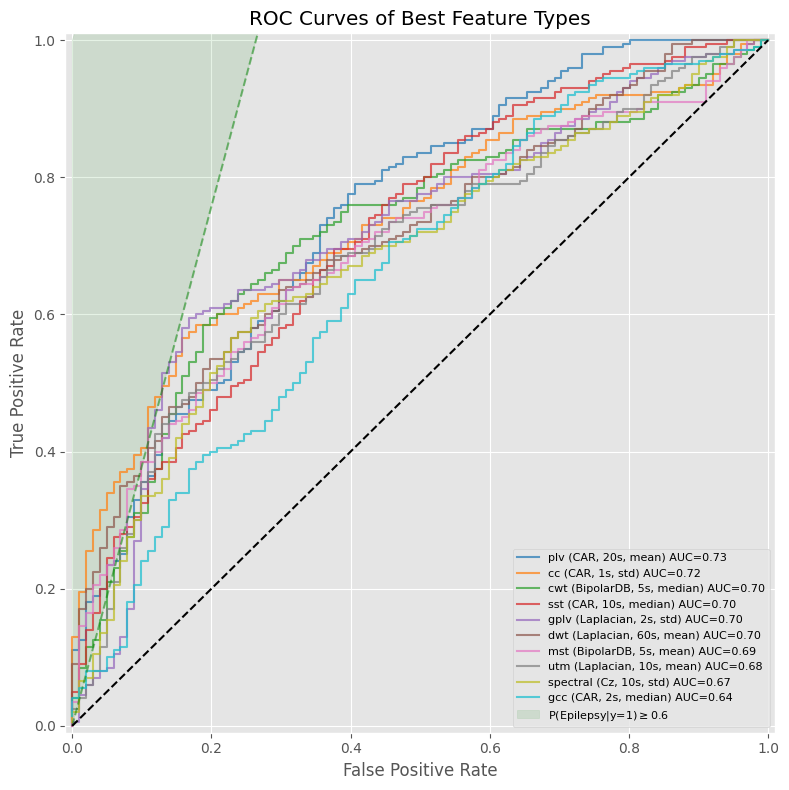

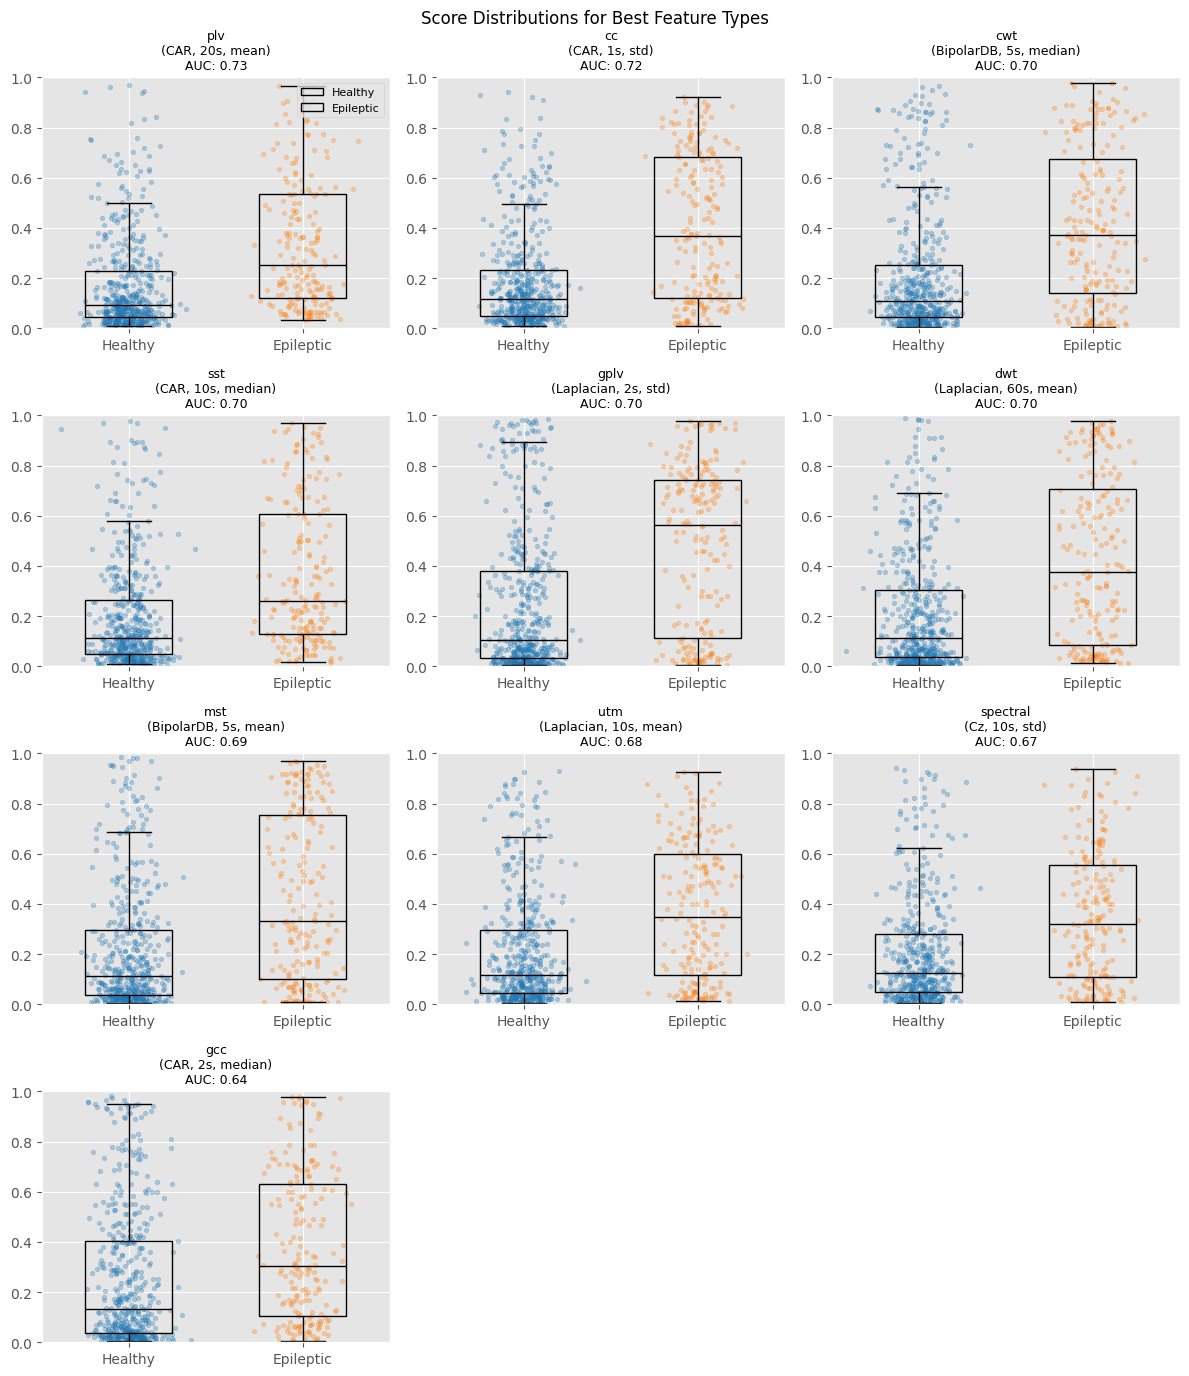

Analyzing data from: /space/gzanardini/emc/emc_background
Found 7000 prediction files.
Processing feature type: spectral with 700 files
Processing feature type: cwt with 700 files


In [ ]:
for path in available_paths:
    df_summary = None
    if os.path.exists(path):
        df_summary = analyze_set_performance(path, save_plots=True, plot_prefix=path.split('/')[-2])
